In [1]:
# First, install the neuralforecast package
#!pip install neuralforecast

import pandas as pd
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data


df = pd.read_csv('fromCale/daily_data_nl.csv')
df


,utc_timestamp,NL_load_actual_entsoe_transparency
0,2015-01-01 00:00:00+00:00,10283.833333
1,2015-01-02 00:00:00+00:00,11931.250000
2,2015-01-03 00:00:00+00:00,12920.250000
3,2015-01-04 00:00:00+00:00,12529.250000
4,2015-01-05 00:00:00+00:00,15715.708333
...,...,...
1821,2019-12-27 00:00:00+00:00,13221.916667
1822,2019-12-28 00:00:00+00:00,12964.208333
1823,2019-12-29 00:00:00+00:00,12607.125000
1824,2019-12-30 00:00:00+00:00,13258.166667


## Training

In [3]:
# Select data for training # 
fra = '2018-01-01'
til = '2018-10-31'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
trainData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
trainData = trainData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'y'})
trainData['unique_id'] = 'METER_01' # Identitas unik
trainData = trainData[['unique_id', 'ds', 'y']]
trainData['ds'] = pd.to_datetime(trainData['ds'])
trainData

,unique_id,ds,y
1096,METER_01,2018-01-01 00:00:00+00:00,11692.250000
1097,METER_01,2018-01-02 00:00:00+00:00,14106.333333
1098,METER_01,2018-01-03 00:00:00+00:00,14755.000000
1099,METER_01,2018-01-04 00:00:00+00:00,14686.291667
1100,METER_01,2018-01-05 00:00:00+00:00,14471.375000
...,...,...,...
1394,METER_01,2018-10-26 00:00:00+00:00,13899.416667
1395,METER_01,2018-10-27 00:00:00+00:00,12058.791667
1396,METER_01,2018-10-28 00:00:00+00:00,11434.458333
1397,METER_01,2018-10-29 00:00:00+00:00,14216.250000


In [4]:
len(trainData)

303

## Validatian


In [5]:
# Select data for validation # 
fra = '2018-11-01'
til = '2018-12-31'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
validData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
validData = validData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'actual'})
validData

,ds,actual
1400,2018-11-01 00:00:00+00:00,14215.291667
1401,2018-11-02 00:00:00+00:00,13921.708333
1402,2018-11-03 00:00:00+00:00,12497.916667
1403,2018-11-04 00:00:00+00:00,11785.500000
1404,2018-11-05 00:00:00+00:00,14103.208333
1405,2018-11-06 00:00:00+00:00,14015.291667
1406,2018-11-07 00:00:00+00:00,14273.708333
1407,2018-11-08 00:00:00+00:00,14009.458333
1408,2018-11-09 00:00:00+00:00,14067.333333
1409,2018-11-10 00:00:00+00:00,12637.375000


In [6]:
len(validData)

60

## Forecast

In [7]:
# 3. Konfigurasi Model
# h: berapa langkah ke depan yang ingin diprediksi
# input_size: berapa langkah ke belakang yang dilihat model
horizon = len(validData)  # Contoh: prediksi 24 jam ke depan
model = NHITS(
    h=horizon,
    input_size=len(trainData), 
    #input_size=horizon*5, 
    start_padding_enabled=True,  # Melihat tren 1 minggu terakhir
    loss=MAE(),                  # Metrik evaluasi
    max_steps=1000,               # Jumlah training iterations
    n_freq_downsample=[30, 7, 1], # Menangkap pola harian, 12-jam, dan jam-jaman
    early_stop_patience_steps=10  # Berhenti jika akurasi tidak membaik
)


Seed set to 1


In [8]:
# 4. Inisialisasi dan Training

nf = NeuralForecast(models=[model], freq='D')

nf.fit(df=trainData, val_size=horizon)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  3.2 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_steps=1000` reached.


In [9]:
# 5. Forecasting
fcst_df = nf.predict()
fcst_df


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


,unique_id,ds,NHITS
0,METER_01,2018-10-31 00:00:00+00:00,14267.035156
1,METER_01,2018-11-01 00:00:00+00:00,14416.208984
2,METER_01,2018-11-02 00:00:00+00:00,13984.702148
3,METER_01,2018-11-03 00:00:00+00:00,13140.642578
4,METER_01,2018-11-04 00:00:00+00:00,11774.602539
5,METER_01,2018-11-05 00:00:00+00:00,13494.163086
6,METER_01,2018-11-06 00:00:00+00:00,14108.001953
7,METER_01,2018-11-07 00:00:00+00:00,14206.676758
8,METER_01,2018-11-08 00:00:00+00:00,14236.209961
9,METER_01,2018-11-09 00:00:00+00:00,14018.260742


# Merge DataFrame

In [10]:
# Convert the 'ds' column in both DataFrames to the same data type (datetime)
fcst_df['ds'] = pd.to_datetime(fcst_df['ds'])
validData['ds'] = pd.to_datetime(validData['ds'])

# Now merge the DataFrames
result = pd.merge(fcst_df, validData, on='ds', how='inner')

In [11]:
result

,unique_id,ds,NHITS,actual
0,METER_01,2018-11-01 00:00:00+00:00,14416.208984,14215.291667
1,METER_01,2018-11-02 00:00:00+00:00,13984.702148,13921.708333
2,METER_01,2018-11-03 00:00:00+00:00,13140.642578,12497.916667
3,METER_01,2018-11-04 00:00:00+00:00,11774.602539,11785.500000
4,METER_01,2018-11-05 00:00:00+00:00,13494.163086,14103.208333
5,METER_01,2018-11-06 00:00:00+00:00,14108.001953,14015.291667
6,METER_01,2018-11-07 00:00:00+00:00,14206.676758,14273.708333
7,METER_01,2018-11-08 00:00:00+00:00,14236.209961,14009.458333
8,METER_01,2018-11-09 00:00:00+00:00,14018.260742,14067.333333
9,METER_01,2018-11-10 00:00:00+00:00,13093.545898,12637.375000


In [12]:

import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['actual'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['actual'] - result['NHITS']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['actual'] - result['NHITS'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)



rRMSE: 0.0628 rMAE: 0.0492 


In [15]:
city = 'Daily The Netherland NHITS'

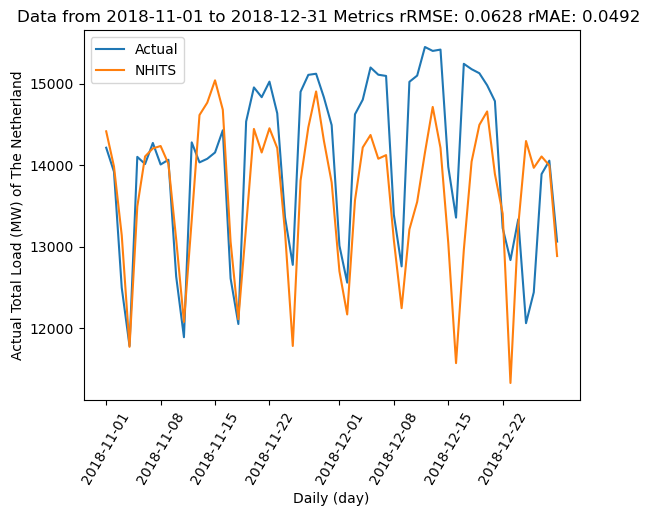

In [17]:
# plot Result dan save

plt.plot(result['ds'], result['actual'], label='Actual')
plt.plot(result['ds'], result['NHITS'],label='NHITS')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Daily (day)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of The Netherland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()
